有效圈数据量： 9
             mean       std     min     max
Driver                                     
HAM     98.930000  0.240416  98.760  99.100
LEC     97.965000  0.219203  97.810  98.120
RUS     99.125000  0.289914  98.920  99.330
VER     97.931667  0.661969  97.492  98.693
[1.201 0.    0.118 0.628 0.318 1.608 1.268 1.838 1.428]


C:\Users\陈词年\AppData\Local\Temp\ipykernel_11744\3292812938.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_laps["lap_sec"] = valid_laps["LapTime"].dt.total_seconds()


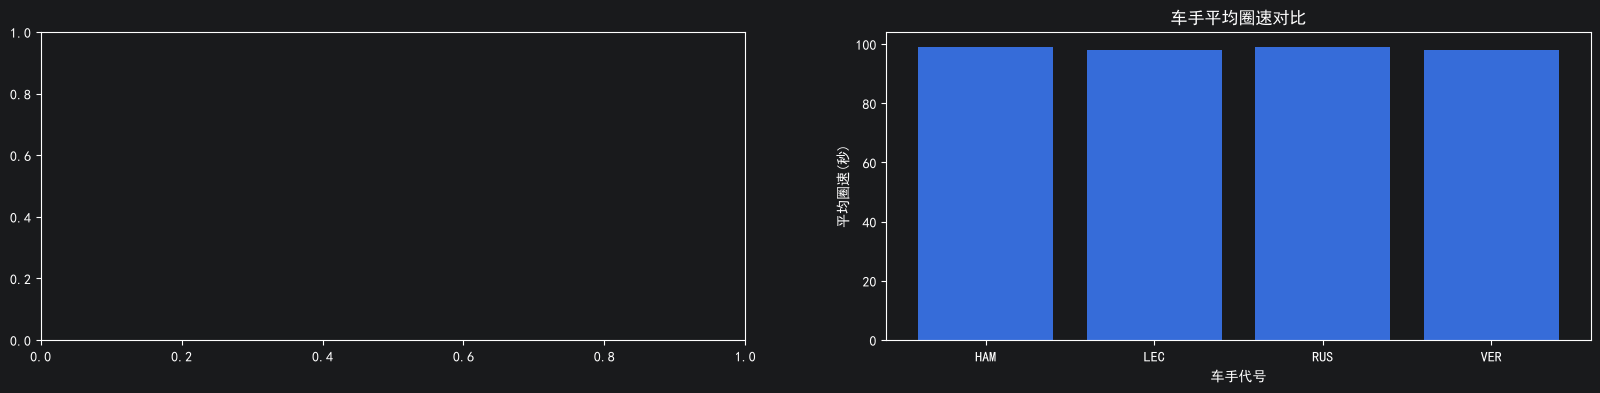

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ["SimHei"]
plt.rcParams['axes.unicode_minus'] = False

# 修复：统一写成 00:01:38.693 标准 hh:mm:ss.fff 格式
sim_data = [
    {"Driver":"VER","LapNumber":1,"LapTime":"00:01:38.693","Compound":"Soft","PitInTime":None},
    {"Driver":"VER","LapNumber":2,"LapTime":"00:01:37.492","Compound":"Soft","PitInTime":None},
    {"Driver":"VER","LapNumber":3,"LapTime":"00:01:37.610","Compound":"Soft","PitInTime":None},
    {"Driver":"LEC","LapNumber":1,"LapTime":"00:01:38.120","Compound":"Soft","PitInTime":None},
    {"Driver":"LEC","LapNumber":2,"LapTime":"00:01:37.810","Compound":"Soft","PitInTime":None},
    {"Driver":"LEC","LapNumber":3,"LapTime":None,"Compound":"Soft","PitInTime":"00:01:42.100"},
    {"Driver":"HAM","LapNumber":1,"LapTime":"00:01:39.100","Compound":"Medium","PitInTime":None},
    {"Driver":"HAM","LapNumber":2,"LapTime":"00:01:38.760","Compound":"Medium","PitInTime":None},
    {"Driver":"RUS","LapNumber":1,"LapTime":"00:01:39.330","Compound":"Medium","PitInTime":None},
    {"Driver":"RUS","LapNumber":2,"LapTime":"00:01:38.920","Compound":"Medium","PitInTime":None},
]

laps = pd.DataFrame(sim_data)

# 时间转换
laps["LapTime"] = pd.to_timedelta(laps["LapTime"])
valid_laps = laps[(laps["LapTime"].notna()) & (laps["PitInTime"].isna())]
valid_laps["lap_sec"] = valid_laps["LapTime"].dt.total_seconds()

print("有效圈数据量：", len(valid_laps))


group=valid_laps.groupby("Driver")["lap_sec"]
stat =group.agg(["mean","std","min","max"])
print(stat)

lap_sec = valid_laps["LapTime"].dt.total_seconds().to_numpy()
gap=lap_sec-lap_sec.min()
print(gap)
plt.subplots(nrows=1,ncols=2,figsize=(20,4))

plt.bar(stat.index,stat["mean"])
plt.title("车手平均圈速对比")
plt.xlabel("车手代号")
plt.ylabel("平均圈速(秒)")
plt.show()


In [2]:
t1=(10,20)
b,a=t1
print(a,b)

20 10
